In [1]:
from eeg_bci.data.paths import resolve_data_dir

data_dir = resolve_data_dir("/workspaces/BRAINDECODE/data/moabb")
data_dir

PosixPath('/workspaces/BRAINDECODE/data/moabb')

In [2]:
from braindecode.datasets import MOABBDataset
import moabb

moabb.set_download_dir(str(data_dir))

subject_id = 3
dataset = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[subject_id])

In [3]:
import numpy as np

from braindecode.preprocessing import (
    Preprocessor,
    exponential_moving_standardize,
    preprocess,
)

low_cut_hz = 4.0  # low cut frequency for filtering
high_cut_hz = 38.0  # high cut frequency for filtering
# Parameters for exponential moving standardization
factor_new = 1e-3
init_block_size = 1000

preprocessors = [
    Preprocessor("pick_types", eeg=True, meg=False, stim=False),  # Keep EEG sensors
    Preprocessor(
        lambda data, factor: np.multiply(data, factor),  # Convert from V to uV
        factor=1e6,
    ),
    Preprocessor("filter", l_freq=low_cut_hz, h_freq=high_cut_hz),  # Bandpass filter
    Preprocessor(
        exponential_moving_standardize,  # Exponential moving standardization
        factor_new=factor_new,
        init_block_size=init_block_size,
    ),
]

# Preprocess the data
preprocess(dataset, preprocessors, n_jobs=-1)

/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(
/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:76: UserWarning: Preprocessing choices with lambda functions cannot be saved.
  warn("Preprocessing choices with lambda functions cannot be saved.")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 38 Hz

FIR filter parameters
---------------------
Designing a one-pass, 

<BaseConcatDataset | 12 RawDataset(s) | 1160820 total samples>
  Sfreq*: 250.0 Hz
  Channels*: 22 (22 EEG)
  Ch. names*: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, ... (+12 more)
  Montage*: head
  Duration*: 386.9 s
  (* from first recording)
  Description: 12 recordings × 3 columns [subject, session, run]

In [4]:
from braindecode.preprocessing import create_windows_from_events

trial_start_offset_seconds = -0.5
# Extract sampling frequency, check that they are same in all datasets
sfreq = dataset.datasets[0].raw.info["sfreq"]
assert all([ds.raw.info["sfreq"] == sfreq for ds in dataset.datasets])
# Calculate the window start offset in samples.
trial_start_offset_samples = int(trial_start_offset_seconds * sfreq)

# Create windows using braindecode function for this. It needs parameters to
# define how windows should be used.
windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=trial_start_offset_samples,
    trial_stop_offset_samples=0,
    preload=True,
)

In [9]:
print(windows_dataset.description)
print(len(windows_dataset))

metadata = windows_dataset.get_metadata()
print(metadata.head())
print(metadata.shape)
print(metadata["target"].value_counts())

    subject session run
0         3  0train   0
1         3  0train   1
2         3  0train   2
3         3  0train   3
4         3  0train   4
5         3  0train   5
6         3   1test   0
7         3   1test   1
8         3   1test   2
9         3   1test   3
10        3   1test   4
11        3   1test   5
576
   i_window_in_trial  i_start_in_trial  i_stop_in_trial  target  subject  \
0                  0               625             1750       1        3   
1                  0              2628             3753       2        3   
2                  0              4546             5671       2        3   
3                  0              6498             7623       1        3   
4                  0              8506             9631       2        3   

  session run  
0  0train   0  
1  0train   0  
2  0train   0  
3  0train   0  
4  0train   0  
(576, 7)
target
1    144
2    144
0    144
3    144
Name: count, dtype: int64


In [6]:
splitted = windows_dataset.split("session")
train_set = splitted["0train"]  # Session train
test_set = splitted["1test"]  # Session evaluation

In [7]:
import torch

from braindecode.models import ShallowFBCSPNet
from braindecode.util import set_random_seeds

cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

n_classes = 4
classes = list(range(n_classes))
# Extract number of chans and time steps from dataset
n_channels = windows_dataset[0][0].shape[0]
n_times = windows_dataset[0][0].shape[1]

model = ShallowFBCSPNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    final_conv_length="auto",
)

# Display torchinfo table describing the model
print(model)

# Send model to GPU
if cuda:
    model.cuda()

Layer (type (var_name):depth-idx)             Input Shape               Output Shape              Param #                   Kernel Shape
ShallowFBCSPNet (ShallowFBCSPNet)             [1, 22, 1125]             [1, 4]                    --                        --
├─Ensure4d (ensuredims): 1-1                  [1, 22, 1125]             [1, 22, 1125, 1]          --                        --
├─Rearrange (dimshuffle): 1-2                 [1, 22, 1125, 1]          [1, 1, 1125, 22]          --                        --
├─CombinedConv (conv_time_spat): 1-3          [1, 1, 1125, 22]          [1, 40, 1101, 1]          36,240                    --
├─BatchNorm2d (bnorm): 1-4                    [1, 40, 1101, 1]          [1, 40, 1101, 1]          80                        --
├─Square (conv_nonlin_exp): 1-5               [1, 40, 1101, 1]          [1, 40, 1101, 1]          --                        --
├─AvgPool2d (pool): 1-6                       [1, 40, 1101, 1]          [1, 40, 69, 1]            -- 

In [8]:
from skorch.callbacks import LRScheduler

from braindecode import EEGClassifier

lr = 0.0625 * 0.01
weight_decay = 0
batch_size = 64
n_epochs = 2

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs,
)
# Model training for a specified number of epochs. `y` is None as it is already supplied
# in the dataset.
clf.fit(train_set, y=None)

# evaluated the model after training
y_test = test_set.get_metadata().target
test_acc = clf.score(test_set, y=y_test)
print(f"Test acc: {(test_acc * 100):.2f}%")

  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2500        1.6341  0.0006  0.9713
      2            0.2500        1.3826  0.0000  0.8117
Test acc: 25.00%


<Axes: title={'center': 'Train-Test split'}, xlabel='Number of samples.'>

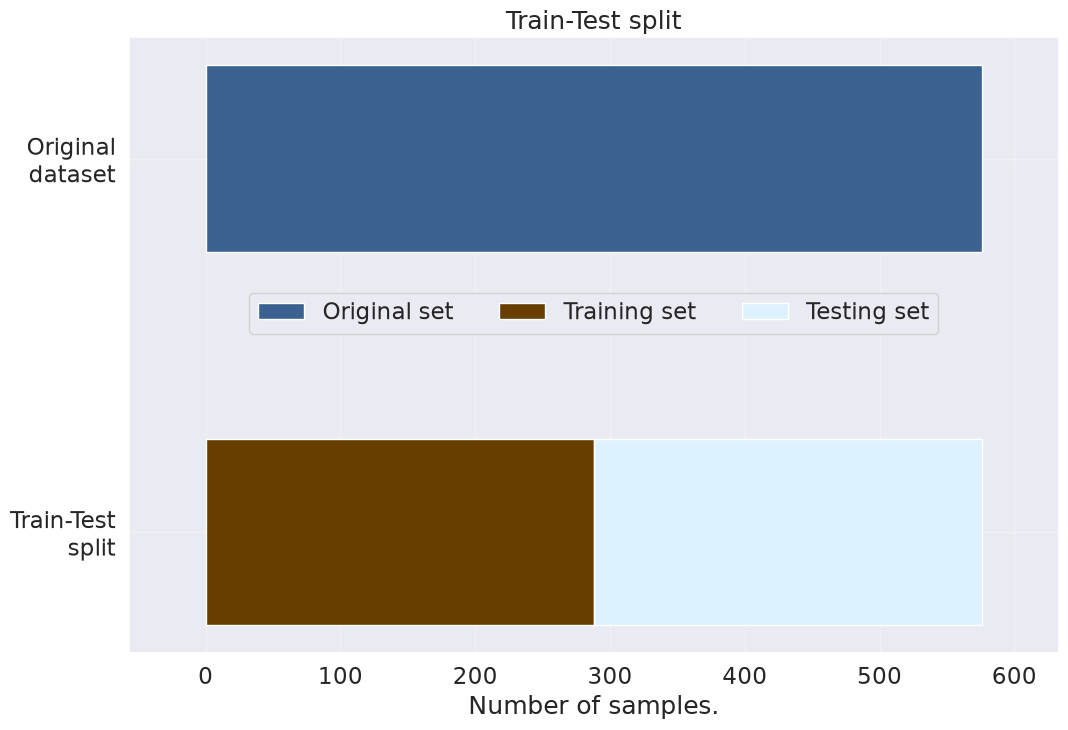

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set(font_scale=1.5)


def plot_simple_train_test(ax, all_dataset, train_set, test_set):
    """Create a sample plot for training-testing split."""
    bd_cmap = ["#3A6190", "#683E00", "#DDF2FF", "#2196F3"]

    ax.barh("Original\ndataset", len(all_dataset), left=0, height=0.5, color=bd_cmap[0])
    ax.barh("Train-Test\nsplit", len(train_set), left=0, height=0.5, color=bd_cmap[1])
    ax.barh(
        "Train-Test\nsplit",
        len(test_set),
        left=len(train_set),
        height=0.5,
        color=bd_cmap[2],
    )

    ax.invert_yaxis()
    ax.set(xlabel="Number of samples.", title="Train-Test split")
    ax.legend(
        ["Original set", "Training set", "Testing set"],
        loc="lower center",
        ncols=4,
        bbox_to_anchor=(0.5, 0.5),
    )
    ax.set_xlim([-int(0.1 * len(all_dataset)), int(1.1 * len(all_dataset))])
    return ax


fig, ax = plt.subplots(figsize=(12, 8))
plot_simple_train_test(
    ax=ax, all_dataset=windows_dataset, train_set=train_set, test_set=test_set
)

In [12]:
from sklearn.model_selection import train_test_split
from skorch.helper import SliceDataset, predefined_split
from torch.utils.data import Subset

X_train = SliceDataset(train_set, idx=0)
y_train = np.array([y for y in SliceDataset(train_set, idx=1)])
train_indices, val_indices = train_test_split(
    X_train.indices_, test_size=0.2, shuffle=False
)
train_subset = Subset(train_set, train_indices)
val_subset = Subset(train_set, val_indices)

In [13]:
clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=predefined_split(val_subset),
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs,
)
clf.fit(train_subset, y=None)

# evaluate the model after training and validation
y_test = test_set.get_metadata().target
test_acc = clf.score(test_set, y=y_test)
print(f"Test acc: {(test_acc * 100):.2f}%")

  epoch    train_accuracy    train_loss    valid_acc    valid_accuracy    valid_loss      lr     dur
-------  ----------------  ------------  -----------  ----------------  ------------  ------  ------
      1            0.3261        1.1762       0.2931            0.2931        4.9092  0.0006  0.3659
      2            0.3391        1.1504       0.3276            0.3276        4.2917  0.0000  0.4045
Test acc: 26.39%


<Axes: title={'center': 'Train-Test-Valid split'}, xlabel='Number of samples.'>

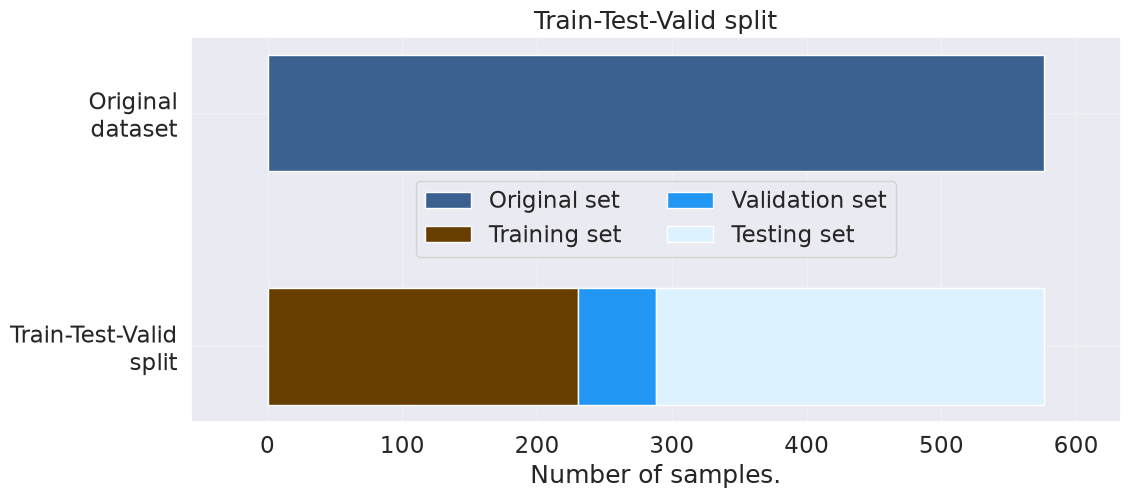

In [14]:
def plot_train_valid_test(ax, all_dataset, train_subset, val_subset, test_set):
    """Create a sample plot for training, validation, testing."""
    bd_cmap = [
        "#3A6190",
        "#683E00",
        "#2196F3",
        "#DDF2FF",
    ]

    n_train, n_val, n_test = len(train_subset), len(val_subset), len(test_set)
    ax.barh("Original\ndataset", len(all_dataset), left=0, height=0.5, color=bd_cmap[0])
    ax.barh("Train-Test-Valid\nsplit", n_train, left=0, height=0.5, color=bd_cmap[1])
    ax.barh(
        "Train-Test-Valid\nsplit", n_val, left=n_train, height=0.5, color=bd_cmap[2]
    )
    ax.barh(
        "Train-Test-Valid\nsplit",
        n_test,
        left=n_train + n_val,
        height=0.5,
        color=bd_cmap[3],
    )

    ax.invert_yaxis()
    ax.set(xlabel="Number of samples.", title="Train-Test-Valid split")
    ax.legend(
        ["Original set", "Training set", "Validation set", "Testing set"],
        loc="lower center",
        ncols=2,
        bbox_to_anchor=(0.5, 0.4),
    )
    ax.set_xlim([-int(0.1 * len(all_dataset)), int(1.1 * len(all_dataset))])
    return ax


fig, ax = plt.subplots(figsize=(12, 5))
plot_train_valid_test(
    ax=ax,
    all_dataset=windows_dataset,
    train_subset=train_subset,
    val_subset=val_subset,
    test_set=test_set,
)



In [15]:
from sklearn.model_selection import KFold, cross_val_score
from skorch.callbacks import LRScheduler

from braindecode import EEGClassifier

lr = 0.0625 * 0.01
weight_decay = 0
batch_size = 64
n_epochs = 2

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs,
)

train_val_split = KFold(n_splits=5, shuffle=False)
# By setting n_jobs=-1, cross-validation is performed
# with all the processors, in this case the output of the training
# process is not printed sequentially
cv_results = cross_val_score(
    clf, X_train, y_train, scoring="accuracy", cv=train_val_split, n_jobs=1
)
print(
    f"Validation accuracy: {np.mean(cv_results * 100):.2f}"
    f"+-{np.std(cv_results * 100):.2f}%"
)

  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2652        1.1800  0.0006  0.3976
      2            0.2739        1.0704  0.0000  0.3442
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2739        1.1930  0.0006  0.3260
      2            0.2957        1.0587  0.0000  0.3299
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.3609        1.2132  0.0006  0.3497
      2            0.3565        1.0497  0.0000  0.3284
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2900        1.1381  0.0006  0.3188
      2            0.2987        1.0374  0.0000  0.3592
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------ 

<Axes: title={'center': 'KFold Train-Test-Valid split'}, xlabel='Number of samples.'>

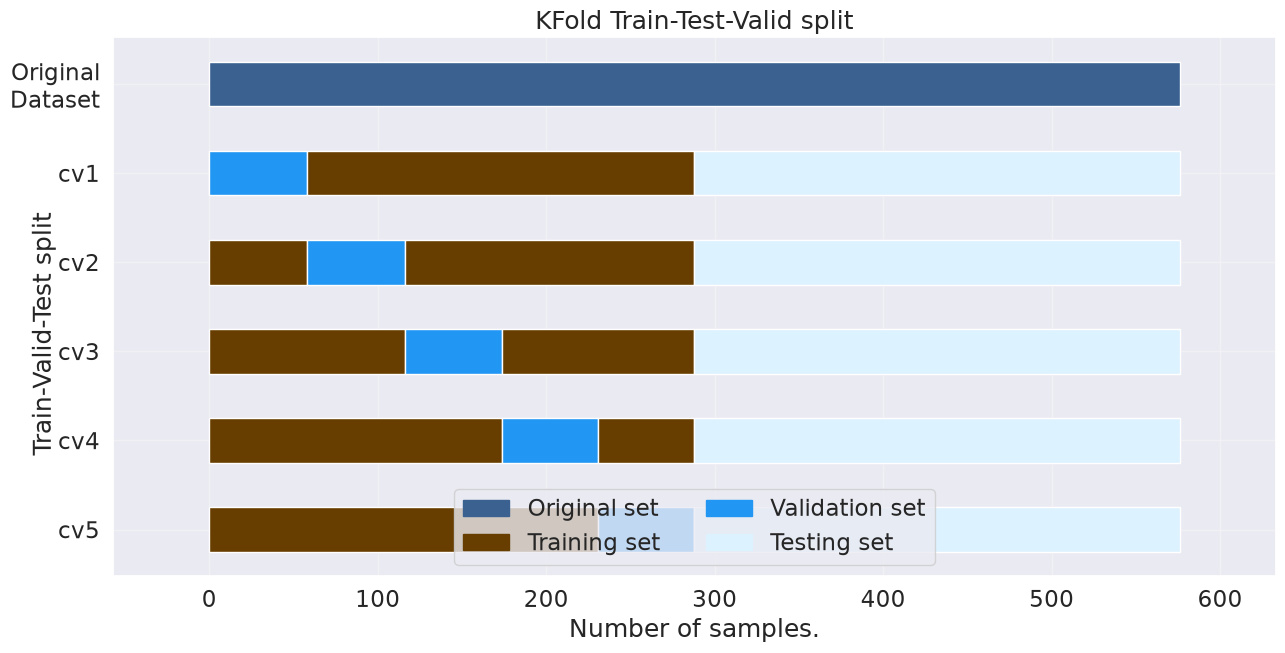

In [16]:
def plot_k_fold(ax, cv, all_dataset, X_train, y_train, test_set):
    """Create a sample plot for training, validation, testing."""
    bd_cmap = [
        "#3A6190",
        "#683E00",
        "#2196F3",
        "#DDF2FF",
    ]

    ax.barh("Original\nDataset", len(all_dataset), left=0, height=0.5, color=bd_cmap[0])

    # Generate the training/validation/testing data fraction visualizations for each CV split
    for ii, (tr_idx, val_idx) in enumerate(cv.split(X=X_train, y=y_train)):
        n_train, n_val, n_test = len(tr_idx), len(val_idx), len(test_set)
        n_train2 = n_train + n_val - max(val_idx) - 1
        ax.barh("cv" + str(ii + 1), min(val_idx), left=0, height=0.5, color=bd_cmap[1])
        ax.barh(
            "cv" + str(ii + 1), n_val, left=min(val_idx), height=0.5, color=bd_cmap[2]
        )
        ax.barh(
            "cv" + str(ii + 1),
            n_train2,
            left=max(val_idx) + 1,
            height=0.5,
            color=bd_cmap[1],
        )
        ax.barh(
            "cv" + str(ii + 1),
            n_test,
            left=n_train + n_val,
            height=0.5,
            color=bd_cmap[3],
        )

    ax.invert_yaxis()
    ax.set_xlim([-int(0.1 * len(all_dataset)), int(1.1 * len(all_dataset))])
    ax.set(xlabel="Number of samples.", title="KFold Train-Test-Valid split")
    ax.legend(
        [Patch(color=bd_cmap[i]) for i in range(4)],
        ["Original set", "Training set", "Validation set", "Testing set"],
        loc="lower center",
        ncols=2,
    )
    ax.text(
        -0.07,
        0.45,
        "Train-Valid-Test split",
        rotation=90,
        verticalalignment="center",
        horizontalalignment="left",
        transform=ax.transAxes,
    )
    return ax


fig, ax = plt.subplots(figsize=(15, 7))
plot_k_fold(
    ax,
    cv=train_val_split,
    all_dataset=windows_dataset,
    X_train=X_train,
    y_train=y_train,
    test_set=test_set,
)

In [17]:
import pandas as pd
from sklearn.model_selection import GridSearchCV

train_val_split = [
    tuple(train_test_split(X_train.indices_, test_size=0.2, shuffle=False))
]

param_grid = {
    "optimizer__lr": [0.00625, 0.000625],
}

# By setting n_jobs=-1, grid search is performed
# with all the processors, in this case the output of the training
# process is not printed sequentially
search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=train_val_split,
    return_train_score=True,
    scoring="accuracy",
    refit=True,
    verbose=1,
    error_score="raise",
    n_jobs=1,
)

search.fit(X_train, y_train)
search_results = pd.DataFrame(search.cv_results_)

best_run = search_results[search_results["rank_test_score"] == 1].squeeze()

best_parameters = best_run["params"]


Fitting 1 folds for each of 2 candidates, totalling 2 fits
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.3304        1.3693  0.0063  0.3547
      2            0.3957        1.3278  0.0000  0.3589
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2783        1.2240  0.0006  0.3320
      2            0.2913        1.0090  0.0000  0.3369
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2639        1.1834  0.0006  0.4584
      2            0.2743        1.0415  0.0000  0.5201


In [18]:
train_val_split = KFold(n_splits=5, shuffle=False)